### **Dự Báo Phụ Tải Điều Độ**

In [ ]:
!pip install tensorflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 106.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.1 MB/s eta 0:00:00


In [ ]:
# @title Tải thư viện
import tensorflow as tf
from tensorflow import keras
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import backend as K
from sklearn import preprocessing

In [ ]:
# @title Tải dữ liệu
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

file_path = '/content/drive/My Drive/Code-1/Thực tập 1-Dự báo phụ tải/powerconsumption.csv'
df = pd.read_csv(file_path)
df.head()

Mounted at /content/drive


,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [ ]:
# @title Chuẩn hoá dữ liệu
# Construction of the series

train_x = tf.convert_to_tensor(train_x)
val_x = tf.convert_to_tensor(val_x)
test_x = tf.convert_to_tensor(test_x)

scaler = preprocessing.MinMaxScaler()
scaler.fit(train_x)

# Lưu scaler vào file
import os
import joblib

# Kiểm tra sự tồn tại của file scaler.pkl
if not os.path.exists('/content/drive/My Drive/Code-1/Thực tập 1-Dự báo phụ tải/scaler.pkl'):
    # Nếu file chưa tồn tại, lưu scaler vào file
    joblib.dump(scaler, '/content/drive/My Drive/Code-1/Thực tập 1-Dự báo phụ tải/scaler.pkl')
    print("Đã lưu scaler vào file 'scaler.pkl'.")
else:
    # Nếu file đã tồn tại, không lưu lại
    print("File 'scaler.pkl' đã tồn tại, không cần lưu lại.")

train_x_norm:  (41932, 4)
[[0.09009059 0.52625122 0.26236099 0.33096978]
 [0.0861464  0.41554498 0.37488572 0.32828267]
 [0.08339908 0.39762263 0.36211608 0.31696846]
 ...
 [0.38878768 0.3000608  0.27647682 0.12897144]
 [0.38960369 0.29956727 0.27699461 0.12797243]
 [0.39123575 0.30433793 0.27880693 0.13068404]]

val_x_norm:  (5241, 4)
[[0.39667602 0.30483146 0.28074863 0.13796264]
 [0.40048418 0.3077925  0.27828907 0.14395677]
 [0.4007562  0.33000071 0.30404941 0.14638295]
 ...
 [0.37981122 0.42520158 0.57576674 0.08248126]
 [0.38253135 0.41331434 0.5704813  0.07456131]
 [0.38416347 0.41283244 0.57009451 0.07300561]]

test_x_norm:  (5243, 4)
[[0.38307539 0.40945904 0.56738731 0.06692421]
 [0.38933167 0.41476009 0.57718476 0.07003561]
 [0.39150777 0.41524198 0.58195458 0.06819705]
 ...
 [0.09936622 0.40970274 0.57949117 0.17361319]
 [0.09550363 0.39318693 0.55919717 0.16642636]
 [0.09066181 0.37730633 0.53711638 0.16233972]]



In [ ]:
import joblib

# Tải scaler từ file
scaler = joblib.load('/content/drive/My Drive/Code-1/Thực tập 1-Dự báo phụ tải/scaler.pkl')

# Sử dụng scaler để chuẩn hóa dữ liệu
train_x_norm = scaler.transform(train_x)
val_x_norm = scaler.transform(val_x)
test_x_norm = scaler.transform(test_x)

print("train_x_norm: ",train_x_norm.shape)
print(train_x_norm);print()

print("val_x_norm: ",val_x_norm.shape)
print(val_x_norm);print()

print("test_x_norm: ",test_x_norm.shape)
print(test_x_norm);print()

In [ ]:
from tensorflow.keras.layers import Lambda

# @title Định nghĩa mô hình
def model_wavenet_timeseries(len_seq, len_out, dim_exo, nb_filters, dim_filters, dilation_depth, use_bias, res_l2, final_l2,batch_size):
  input_shape_exo = tf.keras.Input(shape=(len_seq, dim_exo), name='input_exo')
  input_shape_target = tf.keras.Input(shape=(len_seq, 1), name='input_target')

  input_exo = input_shape_exo
  input_target = input_shape_target

  outputs = []

  # 1st loop: I'll be making multi-step predictions (every prediction will serve as input for the second prediction, when I move the window size...).
  for t in range(len_out):

    # Causal convolution for the 1st input: exogenous series
    # out_exo : (batch_size,len_seq,dim_exo)
    out_exo = Lambda(lambda x: K.temporal_padding(x, padding=((dim_filters - 1), 0)),
                     output_shape=lambda s: (s[0], s[1] + (dim_filters - 1), s[2]))(input_exo)
    out_exo = tf.keras.layers.Conv1D(filters=nb_filters, kernel_size=dim_filters,dilation_rate=1,use_bias=use_bias,activation=None,
                              name='causal_convolution_exo_%i' %t, kernel_regularizer=tf.keras.regularizers.l2(res_l2))(out_exo)

    # Causal convolution for the 2nd input: target series
    # out_target : (batch_size,len_seq,1)
    out_target = Lambda(lambda x: K.temporal_padding(x, padding=((dim_filters - 1), 0)),
                        output_shape=lambda s: (s[0], s[1] + (dim_filters - 1), s[2]))(input_target)
    out_target = tf.keras.layers.Conv1D(filters=nb_filters, kernel_size=dim_filters,dilation_rate=1,use_bias=use_bias,activation=None,
                              name='causal_convolution_target_%i' %t, kernel_regularizer=tf.keras.regularizers.l2(res_l2))(out_target)

    # Frist Layer #1 (See visual Above)
    # Dilated Convolution (1st Layer #1): part of exogenous series(see visual above)
    # skip_exo : (batch_size,len_seq,dim_exo)
    # first_out_exo (the same as skip_exo, before adding the residual connection): (batch_size, len_seq, dim_exo)
    skip_outputs = []
    z_exo = Lambda(lambda x: K.temporal_padding(x, padding=(2*(dim_filters - 1), 0)),
                   output_shape=lambda s: (s[0], s[1] + 2*(dim_filters - 1), s[2]))(out_exo)
    z_exo = tf.keras.layers.Conv1D(filters=nb_filters,kernel_size=dim_filters,dilation_rate=2,use_bias=use_bias,activation="relu",
                              name='dilated_convolution_exo_1_%i' %t, kernel_regularizer=tf.keras.regularizers.l2(res_l2))(z_exo)
    skip_exo = tf.keras.layers.Conv1D(dim_exo, 1, padding='same', use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(res_l2))(z_exo)
    first_out_exo = tf.keras.layers.Conv1D(dim_exo, 1, padding='same', use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(res_l2))(z_exo)

    # Dilated Convolution (1st Layer #1): part of target series(see visual above)
    # skip_target : (batch_size,len_seq,1)
    # first_out_target (the same as skip_target, before adding the residual connection): (batch_size, len_seq,1)
    z_target = Lambda(lambda x: K.temporal_padding(x, padding=(2*(dim_filters - 1), 0)),
                      output_shape=lambda s: (s[0], s[1] + 2*(dim_filters - 1), s[2]))(out_target)
    z_target = tf.keras.layers.Conv1D(filters=nb_filters,kernel_size=dim_filters,dilation_rate=2,use_bias=use_bias,activation="relu",
                              name='dilated_convolution_target_1_%i' %t, kernel_regularizer=tf.keras.regularizers.l2(res_l2))(z_target)
    skip_target = tf.keras.layers.Conv1D(1, 1, padding='same', use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(res_l2))(z_target)
    first_out_target = tf.keras.layers.Conv1D(1, 1, padding='same', use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(res_l2))(z_target)

    # Concatenation of the skip_exo & skip_target AND Saving them as we go through the 1st for loop (through len_seq)
    # skip_exo : (batch_size,len_seq,dim_exo)
    # skip_target : (batch_size,len_seq,1)
    # The concatenation of skip_exo & skip_target : (batch_size,len_seq,dim_exo+1)
    concat_skip = Lambda(lambda x: tf.concat(x, axis=2),
                         output_shape=lambda s: (s[0][0], s[0][1], s[0][2] + s[1][2]))([skip_exo, skip_target])
    skip_outputs.append(concat_skip)

    # Adding the Residual connections of the exogenous series & target series to inputs
    # res_exo_out : (batch_size,len_seq,dim_exo)
    # res_target_out : (batch_size,len_seq,1)
    res_exo_out = tf.keras.layers.Add()([input_exo, first_out_exo])
    res_target_out = tf.keras.layers.Add()([input_target, first_out_target])

    # Concatenation of the updated outputs (after having added the residual connections)
    # out_concat : (batch_size,len_seq,dim_exo+1)
    out_concat = Lambda(lambda x: tf.concat(x, axis=2),
                        output_shape=lambda s: (s[0][0], s[0][1], s[0][2] + s[1][2]))([res_exo_out, res_target_out])
    out = out_concat

    # From 2nd Layer Layer#2 to Final Layer (Layer #L): See Visual above
    # 2nd loop: inner loop (Going through all the intermediate layers)
    # Intermediate dilated convolutions
    for i in range(2, dilation_depth + 1):
      pad_amount = 2**i * (dim_filters - 1)
      z = Lambda(lambda x, pad=pad_amount: K.temporal_padding(x, padding=(pad, 0)),
                 output_shape=lambda s, pad=pad_amount: (s[0], s[1] + pad, s[2]))(out_concat)
      z = tf.keras.layers.Conv1D(filters=nb_filters,kernel_size=dim_filters,dilation_rate=2**i,use_bias=use_bias,activation="relu",
                              name='dilated_convolution_%i_%i' %(i,t), kernel_regularizer=tf.keras.regularizers.l2(res_l2))(z)

      skip_x = tf.keras.layers.Conv1D(dim_exo+1, 1, padding='same', use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(res_l2))(z)
      first_out_x = tf.keras.layers.Conv1D(dim_exo+1, 1, padding='same', use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(res_l2))(z)

      res_x = tf.keras.layers.Add()([out, first_out_x])  #(batch_size,len_seq,dim_exo+1)
      out = res_x
      skip_outputs.append(skip_x)

    # Adding intermediate outputs of all the layers (See Visual above)
    out = tf.keras.layers.Add()(skip_outputs)            #(batch_size,len_seq,dim_exo+1)

    # Output Layer (exogenous series & target series)
    # outputs : (batch_size,1,1) # The predcition Y
    # out_f_exo (will be used to Adjust the input for the following prediction, see below) : (batch_size,len_seq,dim_exo)
    out = tf.keras.layers.Activation('linear', name="output_linear_%i" %t)(out)
    out_f_target = tf.keras.layers.Conv1D(1, 1, padding='same', kernel_regularizer=tf.keras.regularizers.l2(final_l2))(out)
    out_f_exo = tf.keras.layers.Conv1D(dim_exo, 1, padding='same', kernel_regularizer=tf.keras.regularizers.l2(final_l2))(out)
    outputs.append(Lambda(lambda x: x[:, -1:, :], output_shape=lambda s: (s[0], 1, s[2]))(out_f_target))

    # Adjusting the entry of exogenous series,for the following prediction (of MultiStep predictions): see the 1st loop
    # First: concatenate the previous exogenous series input with the final exo_prediction(current exo_prediction)
    new_exo = Lambda(lambda x: tf.concat(x, axis=1),
                     output_shape=lambda s: (s[0][0], s[0][1] + s[1][1], s[0][2]))([
                         input_exo,
                         Lambda(lambda x: x[:, -1:, :], output_shape=lambda s: (s[0], 1, s[2]))(out_f_exo)
                     ])
    # Second, shift the moving window (of len_seq size) by one
    input_exo = Lambda(lambda x: x[:, 1:, :], output_shape=lambda s: (s[0], s[1]-1, s[2]))(new_exo)

    # Adjusting the entry of target series,for the following prediction (of MultiStep predictions): see the 1st loop
    # First: concatenate the previous target series input with the final prediction(current prediction)
    new_target = Lambda(lambda x: tf.concat(x, axis=1),
                        output_shape=lambda s: (s[0][0], s[0][1] + s[1][1], s[0][2]))([
                            input_target,
                            Lambda(lambda x: x[:, -1:, :], output_shape=lambda s: (s[0], 1, s[2]))(out_f_target)
                        ])
    # Second, shift the moving window (of len_seq size) by one
    input_target = Lambda(lambda x: x[:, 1:, :], output_shape=lambda s: (s[0], s[1]-1, s[2]))(new_target)

  # Chuyển đổi danh sách outputs thành tensor với kích thước (batch_size, len_out, 1)
  outputs = Lambda(lambda x: tf.transpose(tf.squeeze(tf.stack(x), axis=-1), perm=[1, 0, 2]),
                   output_shape=lambda s: (None, len_out, 1))(outputs)
  model = tf.keras.Model([input_shape_exo, input_shape_target], outputs)
  return model

In [ ]:
# @title Tạo mô hình

def compute_len_seq(dilation_depth):
  return (2 ** dilation_depth * 2)

nb_filters = 96
dim_filters = 2
dilation_depth = 4     # len_seq = 32
use_bias = True
res_l2 = 0
final_l2 = 0

batch_size = 128
len_out = 18
dim_exo = 4

len_seq = compute_len_seq(dilation_depth)
print(len_seq)

model = model_wavenet_timeseries(len_seq, len_out, dim_exo, nb_filters, dim_filters, dilation_depth, use_bias, res_l2, final_l2,batch_size=batch_size)
model.summary()

32


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_exo (InputLayer)    │ (None, 32, 4)          │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_target (InputLayer) │ (None, 32, 1)          │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda (Lambda)           │ (None, 33, 4)          │              0 │ input_exo[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_1 (Lambda)         │ (None, 33, 1)          │              0 │ input_target[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ causal_convolution_exo_0  │ (None, 32, 96)         │            864 │ lambda[0][0]           │
│ (Conv1D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ causal_convolution_targe… │ (None, 32, 96)         │            288 │ lambda_1[0][0]         │
│ (Conv1D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_2 (Lambda)         │ (None, 34, 96)         │              0 │ causal_convolution_ex… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_3 (Lambda)         │ (None, 34, 96)         │              0 │ causal_convolution_ta… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dilated_convolution_exo_… │ (None, 32, 96)         │         18,528 │ lambda_2[0][0]         │
│ (Conv1D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dilated_convolution_targ… │ (None, 32, 96)         │         18,528 │ lambda_3[0][0]         │
│ (Conv1D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_1 (Conv1D)         │ (None, 32, 4)          │            384 │ dilated_convolution_e… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_3 (Conv1D)         │ (None, 32, 1)          │             96 │ dilated_convolution_t… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 32, 4)          │              0 │ input_exo[0][0],       │
│                           │                        │                │ conv1d_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_1 (Add)               │ (None, 32, 1)          │              0 │ input_target[0][0],    │
│                           │                        │                │ conv1d_3[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_5 (Lambda)         │ (None, 32, 5)          │              0 │ add[0][0], add_1[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_6 (Lambda)         │ (None, 36, 5)          │              0 │ lambda_5[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_7 (Lambda)    

 Total params: 788,484 (3.01 MB)

 Trainable params: 788,484 (3.01 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# @title Dự đoán trên tập kiểm tra

# I saved the best weights by using the ModelCheckPoint callback during the training phase.
weights_path = "/content/drive/My Drive/Code-1/Thực tập 1-Dự báo phụ tải/weights_train_2.hdf5"
model = model_wavenet_timeseries(len_seq, len_out, dim_exo, nb_filters, dim_filters, dilation_depth, use_bias, res_l2, final_l2,batch_size=batch_size)
model.load_weights(weights_path)

In [ ]:
try:
    # Thử tìm TPU (nếu không có thì sẽ ném ValueError)
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.experimental.TPUStrategy(tpu)
    print("Running on TPU:", tpu.master())
except ValueError:
    # Nếu không tìm thấy TPU, kiểm tra GPU
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        strategy = tf.distribute.get_strategy()  # Nếu có GPU, sử dụng GPU
        print("Running on GPU")
    else:
        strategy = tf.distribute.get_strategy()  # Nếu không có GPU, sử dụng CPU
        print("Running on CPU")

# Bên trong scope của strategy, bạn xây dựng và huấn luyện mô hình của mình:
with strategy.scope():
    pred_train = model.predict((x_train[0],x_train[1]),verbose=1,batch_size=batch_size)
    pred_test = model.predict((x_test[0],x_test[1]),verbose=1,batch_size=batch_size)

Running on GPU
982/982 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [ ]:
def reconstruct_original_sequence(data, window_size):
  """
  Khôi phục dữ liệu về dạng chuỗi ban đầu từ dữ liệu đã được biến đổi thành cửa sổ trượt.

  data (np.ndarray): Dữ liệu đã được biến đổi thành cửa sổ trượt, có shape (num_windows, window_size, ...)
  window_size (int): Kích thước của cửa sổ trượt

  np.ndarray: Dữ liệu ban đầu dạng chuỗi
  """
  num_windows, _, *_ = data.shape

  # Lấy cửa sổ đầu tiên làm chuỗi khởi tạo
  original_sequence = data[0, :, 0]

  # Lần lượt nối các giá trị cuối cùng của các cửa sổ còn lại
  for i in range(1, num_windows):
      original_sequence = np.concatenate((original_sequence, data[i, -1:, 0]))

  return original_sequence

# Giả sử y_train và pred_train có shape (125696, 18, 1)
y_train_original = reconstruct_original_sequence(y_train, window_size=18)
pred_train_original = reconstruct_original_sequence(pred_train, window_size=18)

y_test_original = reconstruct_original_sequence(y_test, window_size=18)
pred_test_original = reconstruct_original_sequence(pred_test, window_size=18)

print("Shape of y_train_original:", y_train_original.shape)
print(y_train_original[:5]);print()
print("Shape of pred_train_original:", pred_train_original.shape);
print(pred_train_original[:5]);print()

print("Shape of y_test_original:", y_test_original.shape)
print(y_test_original[:5]);print()
print("Shape of pred_test_original:", pred_test_original.shape);
print(pred_test_original[:5])


Shape of y_train_original: (125713,)
[0.20904131 0.20333153 0.19809757 0.18826407 0.18540917]

Shape of pred_train_original: (125713,)
[0.20975265 0.20349586 0.19858268 0.18794875 0.18414536]

Shape of y_test_original: (15633,)
[0.32144642 0.33016518 0.3469447  0.35533443 0.3650402 ]

Shape of pred_test_original: (15633,)
[0.3216226  0.33027935 0.3466259  0.35463887 0.36385486]


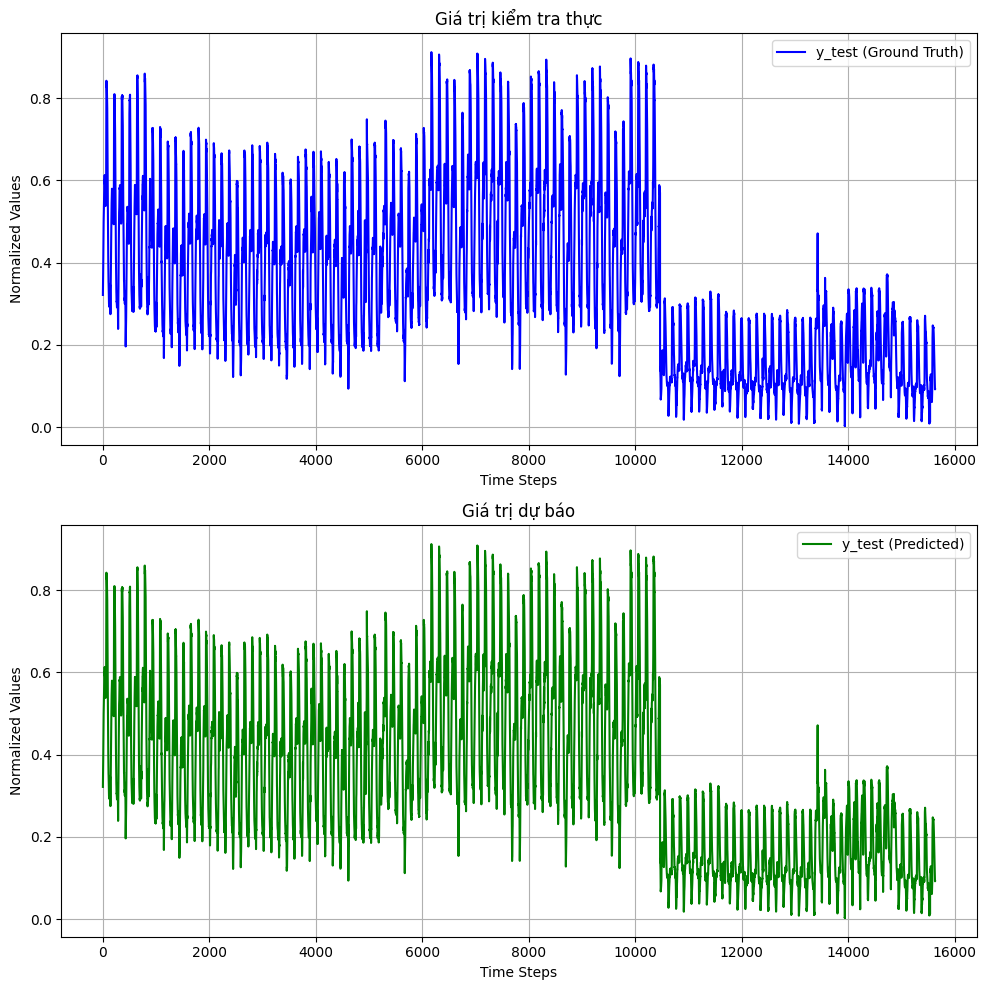

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Biểu đồ cho y_test
ax1.plot(y_test_original, label='y_test (Ground Truth)', color='blue')
ax1.set_title('Giá trị kiểm tra thực')
ax1.set_xlabel('Time Steps')
ax1.set_ylabel('Normalized Values')
ax1.legend()
ax1.grid(True)

# Biểu đồ cho pred_test
ax2.plot(y_test_original, label='y_test (Predicted)', color='green')
ax2.set_title('Giá trị dự báo')
ax2.set_xlabel('Time Steps')
ax2.set_ylabel('Normalized Values')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()